In [252]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
import seaborn as sns
import time
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from torch.utils.data.dataloader import DataLoader
from torch.utils.data.dataset import TensorDataset

plt.style.use("default")

In [237]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [238]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False) # X: (70000, 784)

In [239]:
X, y = mnist["data"], mnist["target"]
X = torch.Tensor(X.astype(np.float32) / 255.0).reshape(-1, 1, 28, 28)
y = torch.Tensor(y.astype(np.int64))
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=10000, random_state=42, stratify=y
)
X_test = X_test.to(device)

In [240]:
X_trainval.shape

torch.Size([60000, 1, 28, 28])

In [241]:
train_dataset = TensorDataset(X_trainval.to(device), y_trainval.to(device))
test_dataset = TensorDataset(X_test.to(device), y_test.to(device))

test_loader = DataLoader(test_dataset, batch_size=1000)

In [242]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()

        # Thanx to https://medium.com/data-science-collective/implementing-cnn-in-pytorch-testing-on-mnist-99-26-test-accuracy-5c63876c6ac8
        self.model = nn.Sequential(
            nn.ZeroPad2d(2),
            nn.Conv2d(1, 16, 5, 1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.LazyLinear(out_features=10),
        )

        self.train_loss_per_epoch = None
        self.val_loss_per_batch = None
        self.best_val_loss = None

    def forward(self, x):
        x = self.model(x)
        return x


In [243]:
def train_one_model(max_epochs: int, batch_size: int, lr: float) -> MLP:
    model = MLP()
    model.to(device)
    model.train()

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    loss_fn = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    n_reports = 10
    print_every = max(max_epochs // n_reports, 1)

    train_loss_per_epoch = np.zeros(max_epochs)
    val_loss_per_batch = np.zeros(max_epochs)

    for epoch in range(max_epochs):
        for data, target in train_loader:
            optimizer.zero_grad()

            y_pred = model(data)

            loss = loss_fn(y_pred, target.long())
            loss.backward()

            optimizer.step()

        model.eval()

        with torch.no_grad():
            loss = 0.0

            for data, target in train_loader:
                y_pred = model(data)
                loss += loss_fn(y_pred, target.long()).item()

            loss_avg = loss / len(train_loader)
            train_loss_per_epoch[epoch] = loss_avg

            loss = 0.0

            for data, target in test_loader:
                y_pred = model(data)
                loss += loss_fn(y_pred, target.long()).item()

            loss_avg = loss / len(test_loader)
            val_loss_per_batch[epoch] = loss_avg

            # if epoch % print_every == 0:
            #     print(f"{epoch=}\tCrossEntropy = {loss_avg:.3f}")

        model.train()

    model.train_loss_per_epoch = train_loss_per_epoch
    model.val_loss_per_batch = val_loss_per_batch
    model.best_val_loss = np.min(val_loss_per_batch).item()

    model.eval()
    return model

In [244]:
batch_sizes = [
    4096,
    2048,
    1024,
    512,
    256,
    128,
    64,
    32,
    16,
    8,
]

learning_rates = [
    0.00001,
    0.0001,
    0.001,
    0.01,
    0.1,
]

models = np.zeros((len(batch_sizes), len(learning_rates)), dtype=object)

training_durations = np.zeros_like(models, dtype=float)

for i, batch_size in enumerate(batch_sizes):
    for j, lr in enumerate(learning_rates):
        lr = 0.1

        start = time.time()
        model = train_one_model(5, batch_size, lr)
        duration = time.time() - start

        models[i, j] = model
        training_durations[i, j] = duration

        perc_done = 100*(i*models.shape[1] + j + 1)//models.size
        print(f"[{perc_done:3n}%] model ({i}, {j}) trained with best val loss = {model.best_val_loss}")

/home/dom/python_global_venvs/ML/venv/lib64/python3.11/site-packages/torch/nn/modules/lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


[  2%] model (0, 0) trained with best val loss = 0.3803024679422379
[  4%] model (0, 1) trained with best val loss = 1.53330500125885
[  6%] model (0, 2) trained with best val loss = 0.44227359890937806
[  8%] model (0, 3) trained with best val loss = 0.4673261374235153
[ 10%] model (0, 4) trained with best val loss = 1.2728389143943786
[ 12%] model (1, 0) trained with best val loss = 0.15580546632409095
[ 14%] model (1, 1) trained with best val loss = 0.4598515868186951
[ 16%] model (1, 2) trained with best val loss = 0.19159603416919707
[ 18%] model (1, 3) trained with best val loss = 0.6635193347930908
[ 20%] model (1, 4) trained with best val loss = 0.3002429336309433
[ 22%] model (2, 0) trained with best val loss = 0.2239622712135315
[ 24%] model (2, 1) trained with best val loss = 0.18782701045274736
[ 26%] model (2, 2) trained with best val loss = 0.12699720486998559
[ 28%] model (2, 3) trained with best val loss = 0.2209637865424156
[ 30%] model (2, 4) trained with best val los

In [245]:
losses = np.vectorize(lambda m: m.best_val_loss)(models)
losses

array([[0.38030247, 1.533305  , 0.4422736 , 0.46732614, 1.27283891],
       [0.15580547, 0.45985159, 0.19159603, 0.66351933, 0.30024293],
       [0.22396227, 0.18782701, 0.1269972 , 0.22096379, 0.31058474],
       [0.29823626, 0.28972877, 0.2431786 , 0.27852243, 0.14447627],
       [0.1761714 , 0.26643294, 2.30310917, 0.26399185, 0.28665941],
       [0.140284  , 0.2790941 , 0.11581547, 0.24228748, 0.22639856],
       [2.30477057, 0.28580103, 0.16870366, 0.17719965, 0.30844321],
       [2.30317531, 0.29371401, 0.29662097, 2.31149735, 2.30888052],
       [2.3091116 , 2.31667573, 2.31785362, 2.30843275, 2.31034832],
       [2.31733479, 2.32562959, 2.31724246, 0.45276325, 0.69334937]])

In [246]:
# Appends the results to the CSV
try:
    df = pd.read_csv("batch_size_losses.csv", header=None)
    df = pd.concat([df, pd.DataFrame(losses)], axis=0)
except FileNotFoundError:
    df = pd.DataFrame(losses)

df.to_csv("batch_size_losses.csv", index=False, header=False)
df

,0,1,2,3,4
0,0.374597,2.301324,0.956208,2.265458,2.301165
1,0.247205,0.387024,2.301224,0.347141,0.464161
2,0.189536,0.293295,2.301641,0.150651,0.323434
3,0.321447,0.275515,0.266691,0.148513,0.286127
4,2.303589,0.153664,0.303408,0.266169,0.136136
5,0.183306,2.304226,0.288853,0.171408,0.272167
6,0.245347,2.303319,2.308307,0.254138,0.305786
7,0.240276,0.266433,2.306788,0.340075,0.332162
8,0.407177,0.461700,2.307509,2.308471,2.306384
9,2.318307,2.316847,2.318332,0.649225,2.309580


In [266]:
losses_combined = np.stack([df[i:i+10] for i in range(0, len(df), 10)])
losses_combined.shape

(2, 10, 5)

In [267]:
# Averaging
losses = losses_combined.mean(axis=0)
losses

array([[0.37744971, 1.91731461, 0.69924093, 1.36639218, 1.78700214],
       [0.2015052 , 0.42343783, 1.24641018, 0.50533025, 0.38220218],
       [0.20674893, 0.2405608 , 1.21431901, 0.18580756, 0.31700947],
       [0.30984158, 0.28262212, 0.25493501, 0.21351754, 0.21530173],
       [1.23987999, 0.21004862, 1.30325846, 0.26508048, 0.21139787],
       [0.16179497, 1.29166014, 0.20233402, 0.20684772, 0.24928255],
       [1.27505881, 1.29455979, 1.23850536, 0.21566864, 0.30711448],
       [1.27172554, 0.28007334, 1.30170451, 1.32578632, 1.3205211 ],
       [1.35814421, 1.38918771, 2.31268146, 2.30845194, 2.30836618],
       [2.31782068, 2.32123851, 2.31778719, 0.55099424, 1.50146455]])

<Axes: >

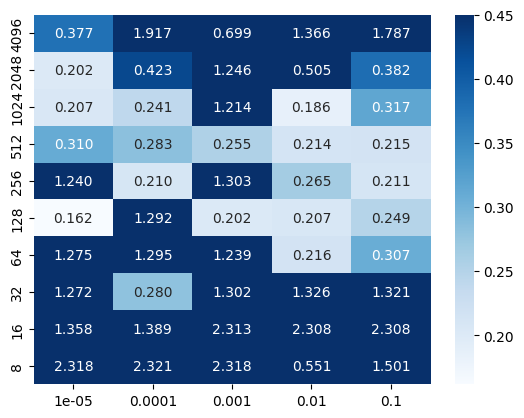

In [268]:
sns.heatmap(losses, annot=True, vmax=0.45, fmt=".3f", xticklabels=learning_rates, yticklabels=batch_sizes, cmap="Blues")

<Axes: >

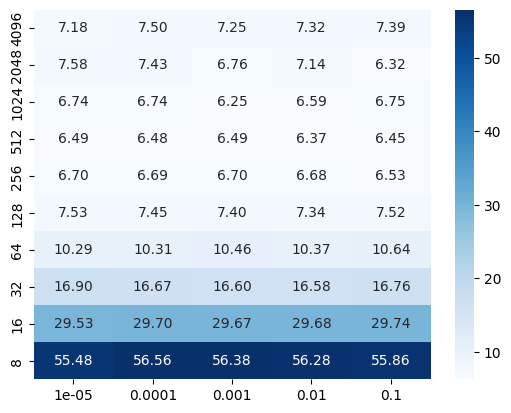

In [254]:
sns.heatmap(training_durations, annot=True, fmt=".2f", xticklabels=learning_rates, yticklabels=batch_sizes, cmap="Blues")

In [249]:
inv_training_eff = losses*training_durations

inv_training_eff

array([[  2.73085165,  11.50680423,   3.20645154,   3.42216811,
          9.41134551],
       [  1.18101256,   3.41682603,   1.2947323 ,   4.73963497,
          1.89783475],
       [  1.50861986,   1.26571622,   0.79352379,   1.45660977,
          2.09790074],
       [  1.93590743,   1.87873184,   1.57900081,   1.77366515,
          0.93167944],
       [  1.18060322,   1.78348706,  15.4273354 ,   1.76462197,
          1.87330368],
       [  1.05566319,   2.07888012,   0.85715312,   1.77782138,
          1.70270394],
       [ 23.71151554,   2.94799598,   1.76430895,   1.8373511 ,
          3.28297604],
       [ 38.92164818,   4.89629033,   4.92483733,  38.32330331,
         38.69102332],
       [ 68.19035722,  68.80465412,  68.78086642,  68.50994766,
         68.70343223],
       [128.5561006 , 131.52623845, 130.63594119,  25.47980616,
         38.73194236]])

<Axes: >

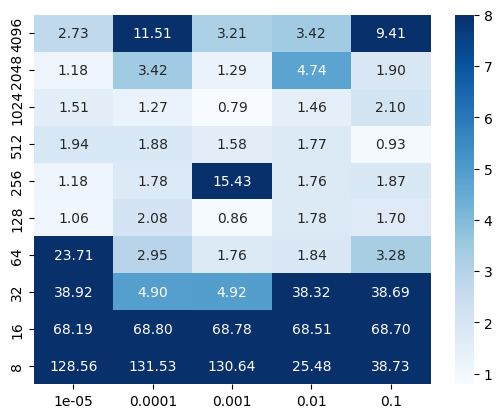

In [255]:
sns.heatmap(inv_training_eff, annot=True, vmax=8, fmt=".2f", xticklabels=learning_rates, yticklabels=batch_sizes, cmap="Blues")

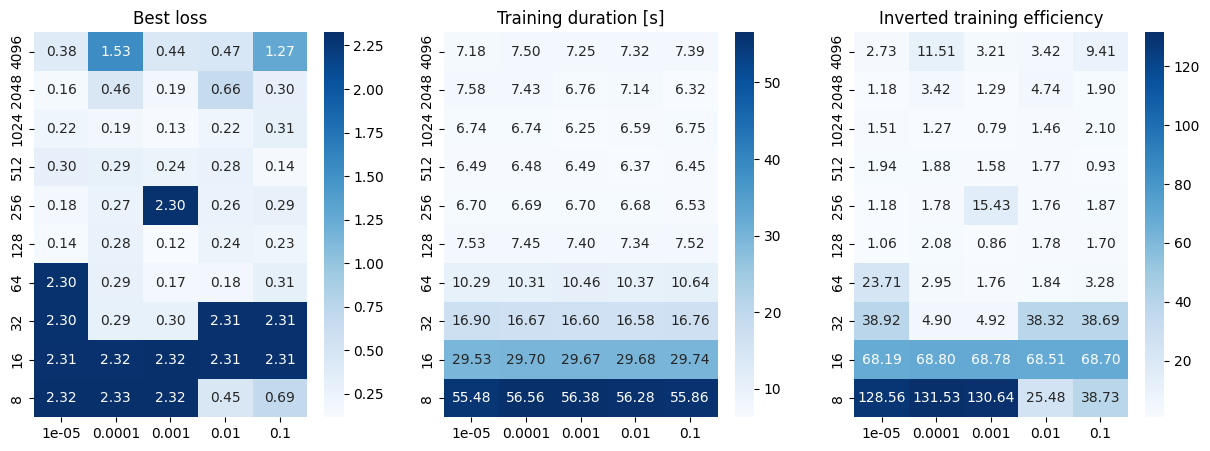

In [256]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

titles = ["Best loss", "Training duration [s]", "Inverted training efficiency"]
for ax, arr, title in zip(axs, [losses, training_durations, inv_training_eff], titles):
    sns.heatmap(arr, annot=True, fmt=".2f", xticklabels=learning_rates, yticklabels=batch_sizes, cmap="Blues", ax=ax)
    ax.set_title(title)

plt.show()
